In [28]:
#packages
import requests
import pandas as pd
import json
from glob import glob
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

import geopandas as gpd

# STEP A — PCA on outage variables (tract-level)

Procedure:

    • Standardize variables
    • Run PCA
    • Keep PC1–PC3 (likely ≥60–80% variance)
    • Extract tract-level PCA scores

Figures:

    • Scree plot
    • Loading plot (which variables drive each PC)
    • Table of PCA scores by tract

In [29]:
#pulling standardized socioeconomic variables
tract_outages = pd.read_csv('data_processed/PCA_data/tract_outages.csv')
tract_outages['TRACT'] = tract_outages['TRACT'].astype(str).str.zfill(6)

In [30]:
#Keeping derived calculations only
features_for_pca = [
    "total_outages",
    "mean_duration_hours",
    "median_duration_hours",
    "max_duration_hours",
    "total_duration_hours",
    "mean_customers_affected",
    "max_customers_affected",
    "total_customers_affected",
    "total_customer_minutes_out",
    "pct_outages_in_summer",
    "pct_outages_in_winter"
]

In [31]:
scaler = StandardScaler()

# RTP county FIPS code
#western_counties = {
#    'Alleghany','Ashe','Avery','Buncombe','Burke','Caldwell','Cherokee','Clay',
#    'Graham','Haywood','Henderson','Jackson','Macon','Madison','McDowell',
#    'Mitchell','Polk','Rutherford','Swain','Transylvania','Watauga','Wilkes','Yancey'
#}

rtp_counties = ['005', '009', '011', '021', '023', '027', '039', '043', '075', 
                '087', '089', '099', '113', '115', '111', '121', '149', '161', 
                '173', '175', '189', '193', '199''005', '009', '011', '021', 
                '023', '027', '039', '043', '075', '087', '089', '099', '113', 
                '115', '111', '121', '149', '161', '173', '175', '189', '193', '199']  

# Ensure TRACT is a string
tract_outages['TRACT'] = tract_outages['TRACT'].astype(str)

# Extract county FIPS (digits 3–5)
tract_outages['county_fips'] = tract_outages['TRACT'].str[2:5]

# Keep only RTP counties - UPDATE I forgote to rename this ha!
tract_outages = tract_outages[
    tract_outages['county_fips'].isin(rtp_counties)
].copy()
 

In [32]:
# Separate features and ID
X = tract_outages.drop(columns=['TRACT'])  
X = X[features_for_pca] 
X = scaler.fit_transform(X[features_for_pca])
tract_ids = tract_outages['TRACT']     

## Scree Plot

To see how many PCs to keep

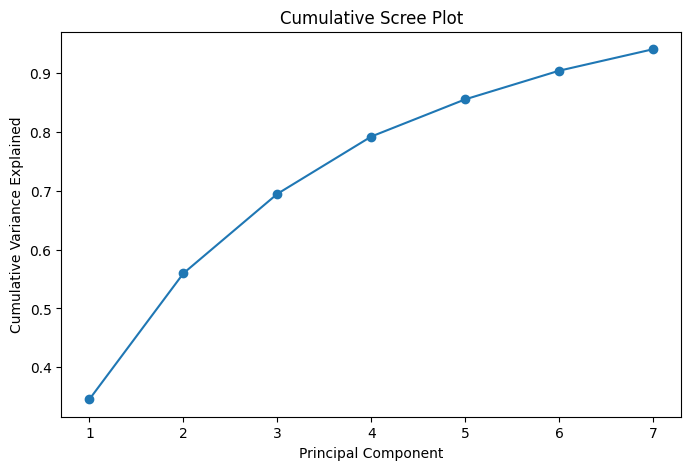

In [33]:
pca = PCA(n_components=7)
pca_scores = pca.fit_transform(X)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(),
         marker='o')

plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Scree Plot")
plt.show()

Planning on using 4 components

## Running PCA for 4 components

In [34]:
# Keeping first two principle components
pca = PCA(n_components=4)
pca_scores = pca.fit_transform(X)

In [35]:
pc_cols = ["PC1", "PC2", "PC3", "PC4"]
outages_tract_pca_scores = pd.DataFrame(pca_scores, columns=pc_cols)

# Add TRACT IDs back
outages_tract_pca_scores["TRACT"] = tract_ids.values

# Create PCA loadings dataframe
outages_tract_loadings = pd.DataFrame(
    pca.components_.T,
    index=features_for_pca,
    columns=pc_cols
)

outages_tract_loadings.to_csv("data_processed/outages_pca_results_WNC/outages_tract_loadings.csv", index=True)


PCA transforms correlated socioeconomic variables into a smaller number of independent components PC1, PC2, PC3, PC4

tract_outages_pca: Displays tract-level PCA scores

PCA Scores: where does each tract lie along these abstract outages axes

Loadings: which variables define each principal component (ie which pattern does PC1, PC2, PC3, and PC4 represent). The are weights linking original variables to each principal component.

## Loadings Interpretation

PC1 High-Impact, High-Risk
High: more total outages, most outages, lots of households affected

PC2 Long-duration
High: longer outages that don't necessarily impact a lot of people

PC3 Customer-intensive, winter-leaning
High: areas that see infrequent outages but they are customer-heavy, that also tend to happen more in the winter

PC4 Rare extreme-duration outages, with low typical impact
High: rare, extreme-duration outages with limited customer impact

# STEP B — Cluster census tracts using PCA scores

Use k-means or hierarchical clustering.

We want to:

    • Cluster tracts based on PC1, PC2, PC3, PC4 scores
    • THEN examine socioeconomic metrics within each cluster

Output per cluster:

    • Socioeconomic profile (low-income, old housing, rural, etc.)
    • Average outage frequency
    • Average outage duration
    • Weather exposure metrics
    
This gives us: which outage types disproportionately affect which communities?

## Choose k (number of clusters)
Via:
- elbow method
- silhouette score

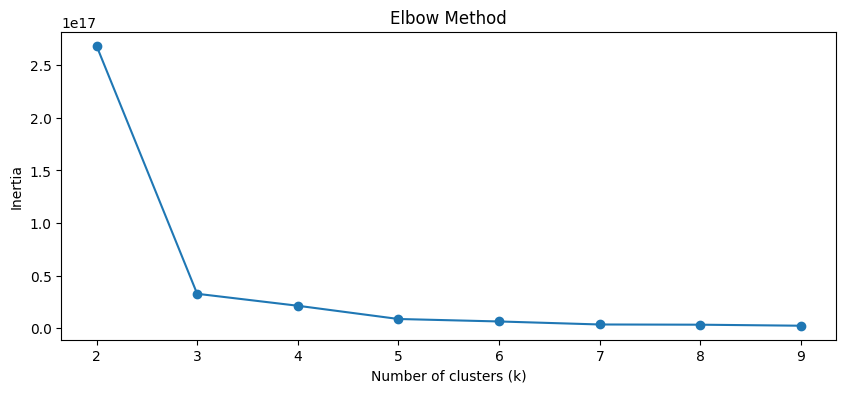

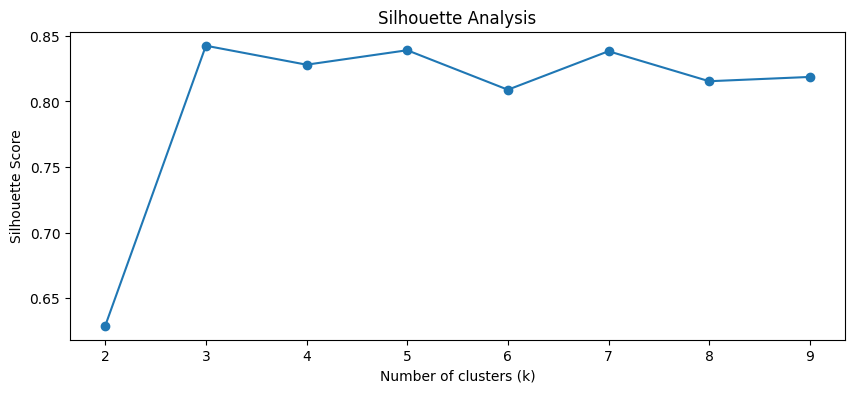

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Ks = range(2, 10)
inertias = []
silhouettes = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(outages_tract_pca_scores)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(outages_tract_pca_scores, labels))

# Plot elbow
plt.figure(figsize=(10,4))
plt.plot(Ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Plot silhouette
plt.figure(figsize=(10,4))
plt.plot(Ks, silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

Choosing k = 3

- Where elbow is most visible before diminishing returns begin
- Has a higher silhouette score than k = 4, 5, 6
    - For silhouette score, it's highest at k = 2, but 2 clusters might oversimpliofy the data

## Run clustering (k-means / hierarchical)

In [37]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42)
outages_tract_pca_scores['cluster'] = kmeans.fit_predict(outages_tract_pca_scores)
outages_tract_pca_scores['cluster'] = outages_tract_pca_scores['cluster'] + 1

## Characterize each cluster

Using the unscaled, real socioeconomic variables.

In [38]:
df = tract_outages.merge(outages_tract_pca_scores[['TRACT','cluster']], on='TRACT')

outages_cluster_profiles = df.groupby('cluster')[features_for_pca].mean()
outages_cluster_profiles.to_csv("data_processed/outages_pca_results_WNC/outages_cluster_profiles.csv", index=True)


Cluster 0 - Moderate frequency, long-duration risk
I am inclined to say this is average impact, it does see longer outages when they happen

Cluster 1 - Low-Impact
Im inclined to also say this is lowest impact, fewest total outages, lowest across most outage categories

Cluster 2 - High-Risk, High-Impact 
This one has the greatest total number of outages, and the largest household-minutes out, so im inclinde to say that this is the highest risk and highest impact

## Identify standout tracts directly using PCA scores and distances

### Identify Outliers Using PCA Distance

In [39]:
pc_df = outages_tract_pca_scores[['PC1','PC2','PC3','PC4']].copy()
pc_df['TRACT'] = outages_tract_pca_scores['TRACT']

pc_df['distance'] = np.sqrt(pc_df['PC1']**2 + pc_df['PC2']**2 + pc_df['PC3']**2 + pc_df['PC4']**2)

#Identifying 20 "outliers"
#pc_df.nlargest(20, 'distance')


### Use hierarchical clustering (Ward’s method)

Hierarchical clustering can reveal:
2 clusters at the top, then splits into smaller subgroups, no assumption of spherical boundaries

And the dendrogram helps tell a story.

Ward's method merges tracts into clusters by minimizing within-group variance. The height of each merge reflects how different two groups are.

In [40]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

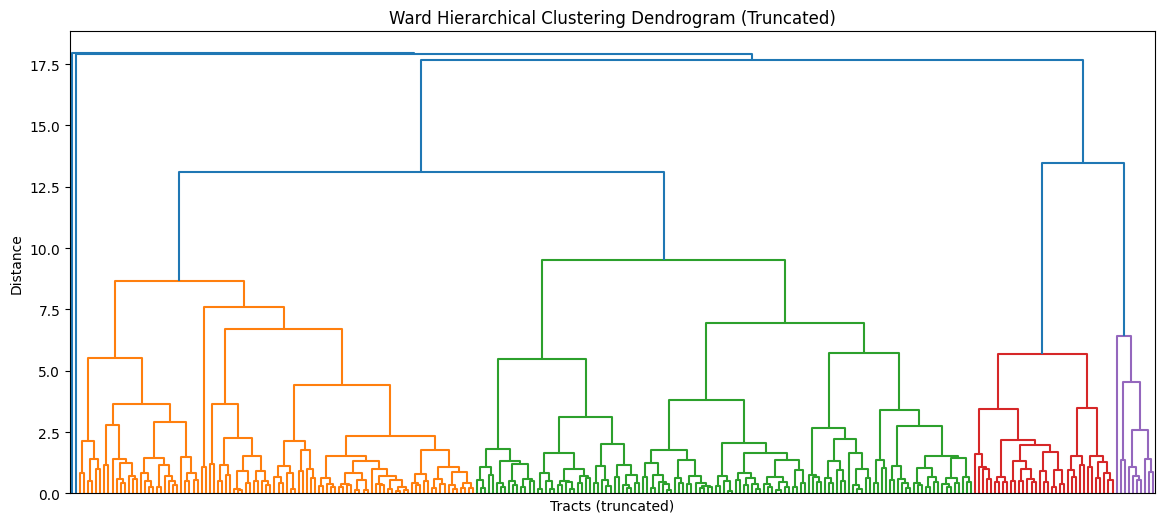

In [41]:
# Use the PCA scores for clustering
X = outages_tract_pca_scores[['PC1', 'PC2', 'PC3','PC4']].reset_index(drop=True)

# Standardize (good practice for hierarchical clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tract_ids = outages_tract_pca_scores['TRACT'].astype(str).reset_index(drop=True)

# Compute hierarchical clustering using Ward's method
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='level',  # show only top hierarchical structure
    p=30,                   # number of leaf nodes to show
    no_labels=True,
)
plt.title("Ward Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Tracts (truncated)")
plt.ylabel("Distance")
plt.show()

### Map PCs or SES variables directly

Map PC1–PC4

In [42]:
tract_geo = gpd.read_file("data_raw/tl_2022_37_tract")
tract_geo['TRACT'] = tract_geo['GEOID'].str[:11]  
tract_geo = tract_geo.to_crs(epsg=4326)

# Merge GeoDataFrame with PCA+cluster data
gdf = tract_geo.merge(
    outages_tract_pca_scores[['TRACT','PC1','PC2','PC3','PC4','cluster']],
    on='TRACT',
    how='left'
)

# Drop tracts missing PCA values (if any)
gdf = gdf.dropna(subset=['PC1','PC2','PC3','PC4','cluster'])

# Ensure GeoDataFrame is in WGS84 (plotly expects EPSG:4326)
gdf = gdf.to_crs(epsg=4326)

# Save an output GeoJSON for other apps / backup
gdf.to_file("data_processed/outages_pca_results_WNC/outages_tracts_with_pca_and_clusters.geojson", driver="GeoJSON")
print("Saved tracts_with_pca_and_clusters.geojson")

Saved tracts_with_pca_and_clusters.geojson


## Loadings Interpretation

PC1 High-Impact, High-Risk
High: more total outages, most outages, lots of households affected

PC2 Long-duration
High: longer outages that don't necessarily impact a lot of people

PC3 Customer-intensive, winter-leaning
High: areas that see infrequent outages but they are customer-heavy, that also tend to happen more in the winter

PC4 Rare extreme-duration outages, with low typical impact
High: rare, extreme-duration outages with limited customer impact

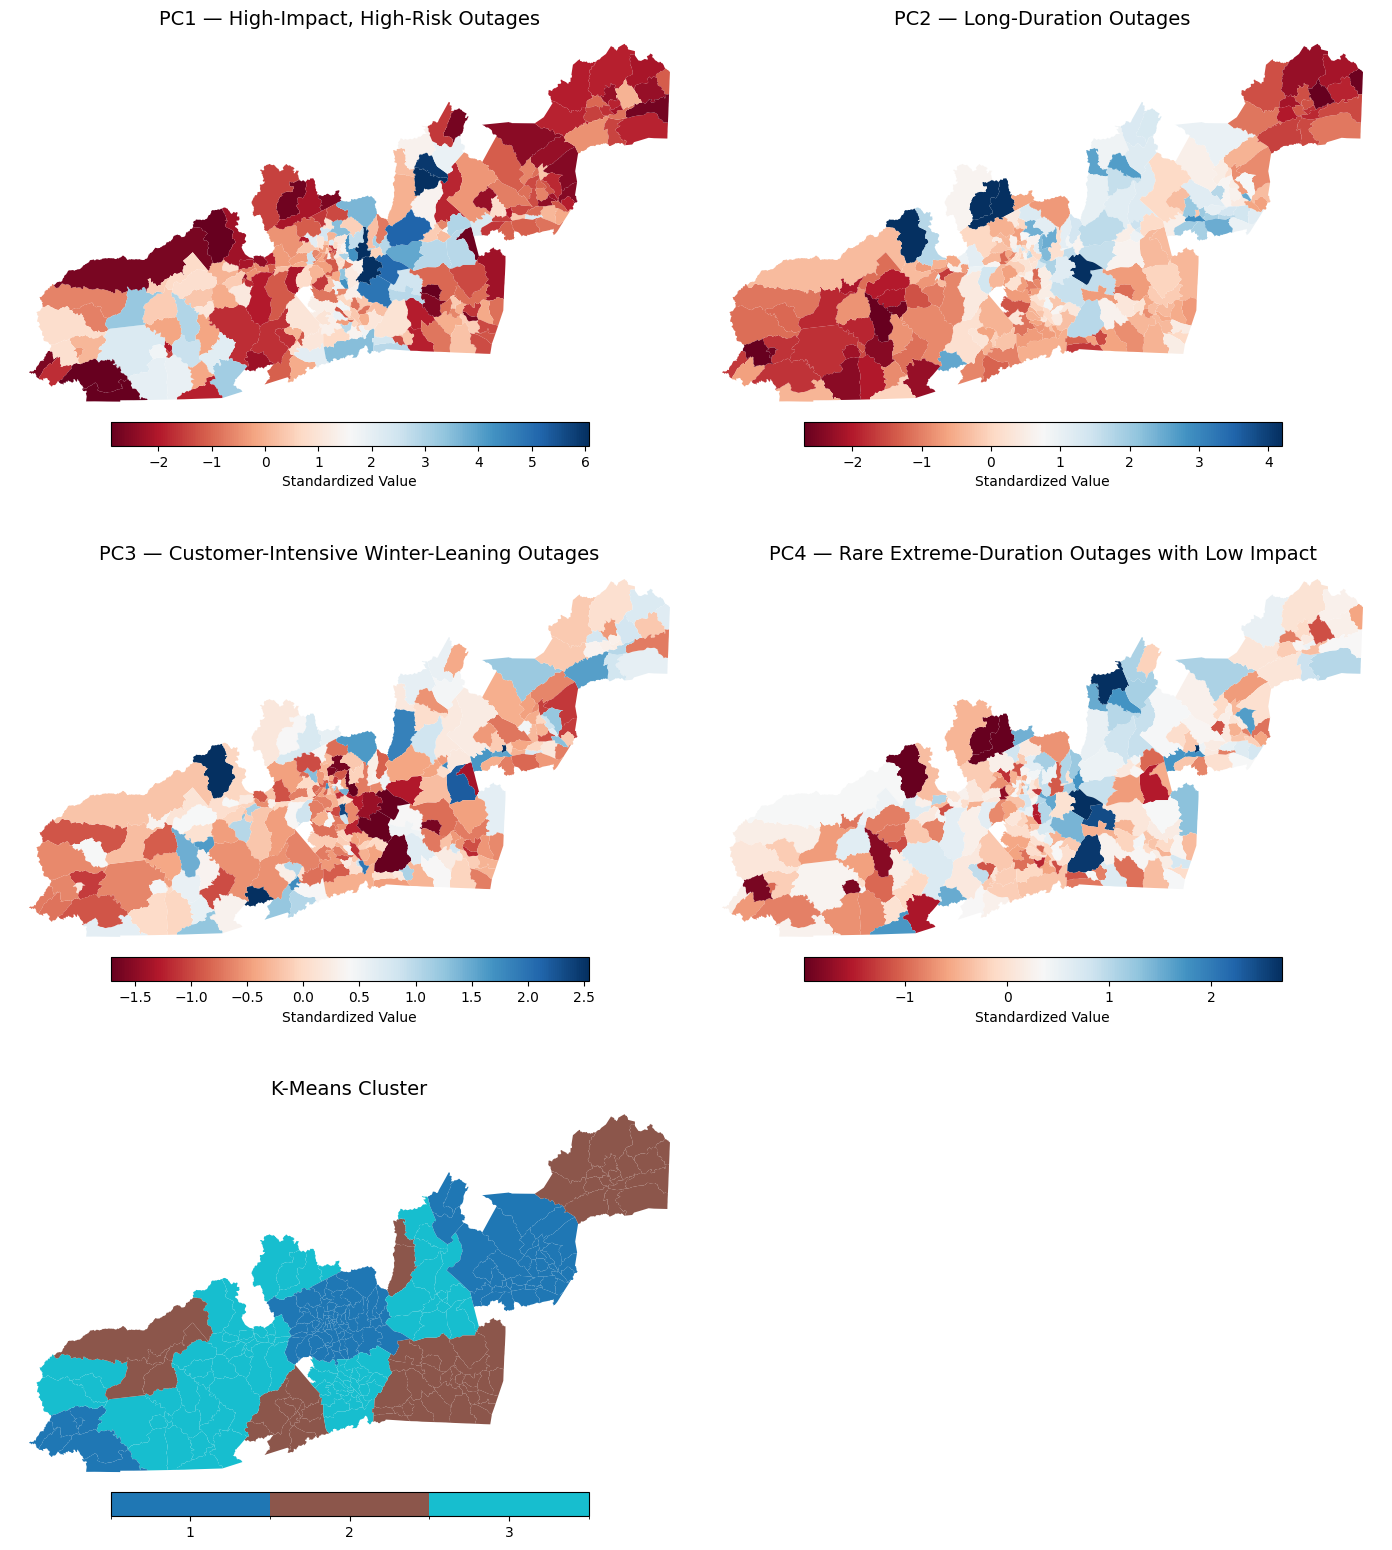

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- ensure cluster is integer ---
gdf['cluster'] = gdf['cluster'].astype('Int64')

variables = ['PC1','PC2','PC3','PC4','cluster']
titles = [
    'PC1 — High-Impact, High-Risk Outages', 
    'PC2 — Long-Duration Outages', 
    'PC3 — Customer-Intensive Winter-Leaning Outages', 
    'PC4 — Rare Extreme-Duration Outages with Low Impact',
    'K-Means Cluster'
]

# --- compute global bounds ---
xmin, ymin, xmax, ymax = gdf.total_bounds
if not np.all(np.isfinite([xmin, ymin, xmax, ymax])):
    xmin, ymin, xmax, ymax = -1, -1, 1, 1

width = max(xmax - xmin, 1e-6)
height = max(ymax - ymin, 1e-6)

pad_x = max(width * 0.03, 0.001 * width)
pad_y = max(height * 0.03, 0.001 * height)

global_xlim = (xmin - pad_x, xmax + pad_x)
global_ylim = (ymin - pad_y, ymax + pad_y)

# --- figure ---
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.ravel()

for i, (var, title) in enumerate(zip(variables, titles)):
    ax = axes[i]

    if gdf.geometry.is_empty.all() or gdf.geometry.isnull().all():
        ax.text(0.5, 0.5, "No geometries to plot", ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    if var == 'cluster':
        # --- discrete cluster ---
        cmap = plt.get_cmap('tab10', 3)
        norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)

        gdf.plot(
            column='cluster',
            ax=ax,
            cmap=cmap,
            norm=norm,
            linewidth=0,
            edgecolor='none',
            legend=False,
            missing_kwds={"color": "lightgrey"}
        )

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm._A = []

        cbar = fig.colorbar(
            sm,
            ax=ax,
            orientation='horizontal',
            fraction=0.05,
            pad=0.02
        )
        cbar.set_ticks([1, 2, 3])
        cbar.set_ticklabels(['1', '2', '3'])

    else:
        # --- robust scaling ---
        col = gdf[var].replace([np.inf, -np.inf], np.nan).dropna()

        if col.empty:
            gdf.plot(ax=ax, color='#EEEEEE', edgecolor='#BBBBBB', linewidth=0.25)
            ax.text(0.5, 0.5, f"No valid values for {var}", ha='center', va='center', transform=ax.transAxes)
        else:
            vmin = col.quantile(0.01)
            vmax = col.quantile(0.99)

            if not np.isfinite(vmin) or not np.isfinite(vmax):
                vmin, vmax = col.min(), col.max()

            if np.isclose(vmin, vmax):
                pad = abs(vmin) * 0.01 if vmin != 0 else 1e-6
                vmin -= pad
                vmax += pad

            cmap = plt.get_cmap('RdBu')
            norm = plt.Normalize(vmin=vmin, vmax=vmax)

            gdf.plot(
                column=var,
                ax=ax,
                cmap=cmap,
                norm=norm,
                linewidth=0,
                edgecolor='none',
                legend=False,
                missing_kwds={"color": "lightgrey"}
            )

            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm._A = []

            cbar = fig.colorbar(
                sm,
                ax=ax,
                orientation='horizontal',
                fraction=0.05,
                pad=0.02
            )
            cbar.set_label("Standardized Value")

    ax.set_xlim(global_xlim)
    ax.set_ylim(global_ylim)
    ax.set_title(title, fontsize=14)
    ax.set_axis_off()

# hide unused subplot
if len(axes) > len(variables):
    axes[len(variables)].set_visible(False)

plt.tight_layout(pad=1.0)

plt.savefig(
    'data_processed/outages_pca_results_WNC/WNC_pca_maps.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [44]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

save_path = "data_processed/outages_pca_results_WNC"
os.makedirs(save_path, exist_ok=True)

# --- ensure cluster is integer ---
gdf['cluster'] = gdf['cluster'].astype('Int64')

variables = ['PC1','PC2','PC3','PC4','cluster']
titles = [
    'PC1 — High-Impact, High-Risk Outages', 
    'PC2 — Long-Duration Outages', 
    'PC3 — Customer-Intensive Winter-Leaning Outages', 
    'PC4 — Rare Extreme-Duration Outages with Low Impact',
    'K-Means Cluster'
]

# --- compute global bounds ---
xmin, ymin, xmax, ymax = gdf.total_bounds
if not np.all(np.isfinite([xmin, ymin, xmax, ymax])):
    xmin, ymin, xmax, ymax = -1, -1, 1, 1

width = max(xmax - xmin, 1e-6)
height = max(ymax - ymin, 1e-6)

pad_x = max(width * 0.03, 0.001 * width)
pad_y = max(height * 0.03, 0.001 * height)

global_xlim = (xmin - pad_x, xmax + pad_x)
global_ylim = (ymin - pad_y, ymax + pad_y)

for var, title in zip(variables, titles):
    plt.close('all')
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    if var not in gdf.columns:
        ax.text(0.5, 0.5, f"{var} not found", ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    if var == 'cluster':
        # --- discrete cluster ---
        cmap = plt.get_cmap('tab10', 3)
        norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)

        gdf.plot(
            column='cluster',
            ax=ax,
            cmap=cmap,
            norm=norm,
            linewidth=0,
            edgecolor='none',
            missing_kwds={"color": "lightgrey"}
        )

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm._A = []

        cbar = fig.colorbar(
            sm,
            ax=ax,
            orientation='horizontal',
            fraction=0.05,
            pad=0.05
        )
        cbar.set_ticks([1, 2, 3])
        cbar.set_ticklabels(['1', '2', '3'])

    else:
        # --- robust scaling ---
        col = gdf[var].replace([np.inf, -np.inf], np.nan).dropna()

        if col.empty:
            gdf.plot(ax=ax, color='#EEEEEE', edgecolor='#BBBBBB', linewidth=0.25)
            ax.text(0.5, 0.5, f"No valid values for {var}", ha='center', va='center', transform=ax.transAxes)
        else:
            vmin = col.quantile(0.01)
            vmax = col.quantile(0.99)

            if not np.isfinite(vmin) or not np.isfinite(vmax):
                vmin, vmax = col.min(), col.max()

            if np.isclose(vmin, vmax):
                pad = abs(vmin) * 0.01 if vmin != 0 else 1e-6
                vmin -= pad
                vmax += pad

            cmap = plt.get_cmap('RdBu')
            norm = plt.Normalize(vmin=vmin, vmax=vmax)

            gdf.plot(
                column=var,
                ax=ax,
                cmap=cmap,
                norm=norm,
                linewidth=0,
                edgecolor='none',
                missing_kwds={"color": "lightgrey"}
            )

            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm._A = []

            cbar = fig.colorbar(
                sm,
                ax=ax,
                orientation='horizontal',
                fraction=0.05,
                pad=0.05
            )
            cbar.set_label("Standardized Value")

    ax.set_xlim(global_xlim)
    ax.set_ylim(global_ylim)
    ax.set_title(title, fontsize=16)
    ax.set_axis_off()

    filename = f"wnc_{var.lower()}_map.png"
    plt.savefig(os.path.join(save_path, filename), dpi=300, bbox_inches='tight')
    plt.close(fig)

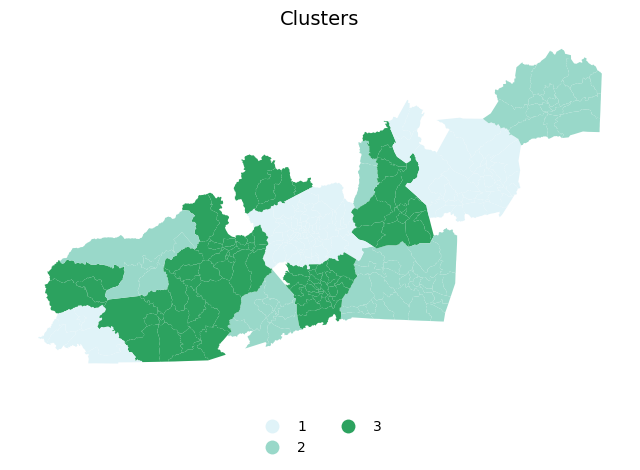

In [45]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Pick your palette
ward_cmap = ListedColormap(['#e0f3f8', '#99d8c9', '#2ca25f'])

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot ward clusters
gdf.plot(
    column='cluster',
    ax=ax,
    categorical=True,
    legend=True,
    cmap=ward_cmap,
    linewidth=0,
    edgecolor='none',
    legend_kwds={
        "ncol": 2,
        "loc": "upper center",
        "bbox_to_anchor": (0.5, -0.08),
        "frameon": False
    }
)

# Styling
ax.set_title('Clusters', fontsize=14)
ax.set_axis_off()

# Save
plt.savefig(
    "data_processed/outages_pca_results_WNC/cluster_map_updated.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Merge with socioeconomic + weather summaries (tract)

I have:
- tract_socioeconomic_unscaled
- tract_weather

Which are summaries of socioeconomics and weather for each tract.

This will help compute:
- Socioeconomic metrics per cluster
- Weather exposure per cluster

In [46]:
tract_socioeconomic = pd.read_csv('data_processed/PCA_data/tract_socioeconomic_unscaled.csv')
tract_weather = pd.read_csv('data_processed/PCA_data/tract_weather.csv')

# Ensure TRACT columns are strings and zero-padded
outages_tract_pca_scores['TRACT'] = outages_tract_pca_scores['TRACT'].astype(str)
tract_socioeconomic['TRACT'] = tract_socioeconomic['TRACT'].astype(str)
tract_weather['TRACT'] = tract_weather['TRACT'].astype(str)
tract_outages['TRACT'] = tract_outages['TRACT'].astype(str)

#MERGE DATSETS
# Merge PCA/cluster -> outages -> weather (left join on PCA tracts)
df = outages_tract_pca_scores[['TRACT','PC1','PC2','PC3','PC4','cluster']].merge(
    tract_socioeconomic, on='TRACT', how='left'
).merge(
    tract_weather, on='TRACT', how='left'
).merge(
    tract_outages, on = 'TRACT', how = 'left'
)


In [47]:
#DEFINING METRICS TO SUMMARIZE (from tract_socioeconomic and tract_weather)
socioeconomic_metrics = [
    'total_population',
    'median_household_income',
    'pct_below_50pct_poverty',
    'pct_no_vehicle',
    'pct_renters_cost_burdened',
    'pct_over65',
    'pct_with_disability',
    'pct_nonwhite'
]

weather_metrics = [
    'max_gust_during_outage_days',
    'mean_wind_on_outage_days',
    'total_precip_on_outage_days',
    'mean_soilmoist_on_outage_days'
]

outage_metrics = [
    'total_outages', 'mean_duration_hours',
    'median_duration_hours', 'max_duration_hours', 'total_duration_hours',
    'mean_customers_affected', 'max_customers_affected',
    'total_customers_affected', 'total_customer_minutes_out',
    'pct_outages_in_summer', 'pct_outages_in_winter'
]

#keeping metrics that exist
metrics = [m for m in (socioeconomic_metrics + weather_metrics + outage_metrics) if m in df.columns]

# Per-cluster summary table (mean, median, std, count)
agg_funcs = {m: ['mean','median','std','count'] for m in metrics}
cluster_summary = df.groupby('cluster').agg(agg_funcs)

# flatten MultiIndex columns
cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.reset_index().sort_values('cluster')

In [48]:
# Per-cluster rates, outages per 1000 people, customer-minutes per capita
df['outages_per_1000'] = df['total_outages'] / df['total_population'] * 1000
df['customer_minutes_per_capita'] = df['total_customer_minutes_out'] / df['total_population']
per_cluster_rates = df.groupby('cluster')[['outages_per_1000','customer_minutes_per_capita']].agg(['mean','median','std']).reset_index()

# STEP C — Identify outlier clusters

Define outliers as:

    • Tracts where outage frequency/duration is > 2 standard deviations above cluster mean
    • Tracts with high weather exposure but low outages (or vice versa)

In [49]:
# Flag per-tract outliers within each cluster (z-score within cluster)
# Compute z-scores within each cluster for a small set of key metrics:
key_metrics = socioeconomic_metrics + weather_metrics
key_metrics = [m for m in key_metrics if m in df.columns]

# compute z-scores grouped by cluster
def z_within_group(group, cols):
    return group[cols].transform(lambda x: (x - x.mean()) / x.std(ddof=0))

zcols = [f"{m}_z_within_cluster" for m in key_metrics]
df[zcols] = z_within_group(df, key_metrics)

# Flag outliers: absolute z > 2 → unusual
for m, zcol in zip(key_metrics, zcols):
    df[f"{m}_is_outlier"] = df[zcol].abs() > 2

# Create an "outlier score" as sum of flags
outlier_flag_cols = [c for c in df.columns if c.endswith('_is_outlier')]
df['outlier_score'] = df[outlier_flag_cols].sum(axis=1)

# Top standout tracts by outlier_score, tiebreaker by max z magnitude
df['max_abs_z'] = df[zcols].abs().max(axis=1)
outlier_list = df.sort_values(['outlier_score','max_abs_z'], ascending=[False, False])

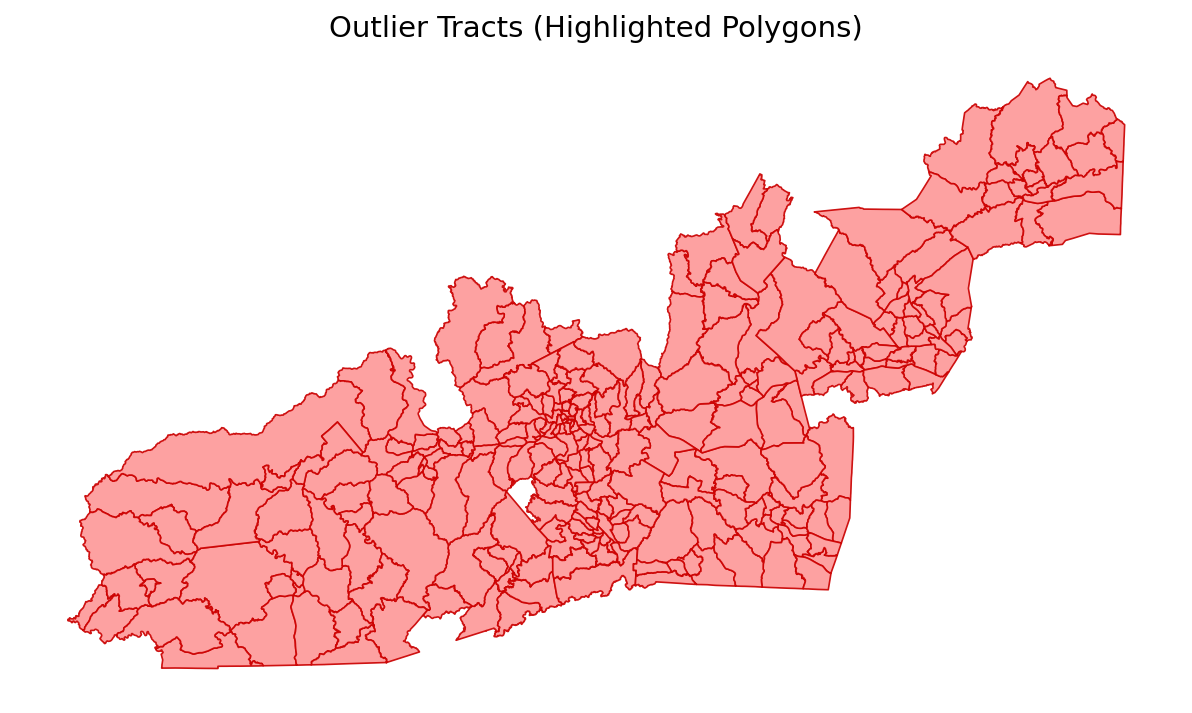

In [50]:
#gdf['TRACT'] = gdf['TRACT'].astype(str).str.zfill(6)
outlier_df = outlier_list.copy()
#outlier_df['TRACT'] = outlier_df['TRACT'].astype(str).str.zfill(6)

# Merge outlier flag into full GeoDataFrame
gdf_map = gdf.merge(
    outlier_df[['TRACT','outlier_score','max_abs_z']],
    on='TRACT',
    how='left'
)

# Outlier polygons only
outlier_gdf = gdf_map[gdf_map['outlier_score'].notna()].copy()

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=150)

# Plot all tracts in very light gray
gdf_map.plot(ax=ax, color='#EDEDED', edgecolor='#AAAAAA', linewidth=0.25)

# Highlight outlier polygons (NO centroids, NO dots)
outlier_gdf.plot(ax=ax,
                 facecolor='#ff9999',   # soft red fill
                 edgecolor='#cc0000',   # darker outline
                 linewidth=0.8,
                 alpha=0.9)

# Clean up
ax.set_axis_off()
ax.set_title("Outlier Tracts (Highlighted Polygons)", fontsize=14)

plt.savefig(
    'data_processed/outages_pca_results_WNC/outlier_tracts_static_map_polygons_only_outages_pca.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [51]:
#SAVE RESULTS
cluster_summary.to_csv("data_processed/outages_pca_results_WNC/cluster_outage_weather_summary.csv", index=False)
df.to_csv("data_processed/outages_pca_results_WNC/tracts_with_clusters_outage_weather.csv", index=False)
outlier_list.to_csv("data_processed/outages_pca_results_WNC/top50_standout_tracts.csv", index=False)
print("Saved cluster_outage_weather_summary.csv, tracts_with_clusters_outage_weather.csv, top50_standout_tracts.csv")

Saved cluster_outage_weather_summary.csv, tracts_with_clusters_outage_weather.csv, top50_standout_tracts.csv


In [52]:
cluster_summary.columns

Index(['cluster', 'total_population_mean', 'total_population_median',
       'total_population_std', 'total_population_count',
       'median_household_income_mean', 'median_household_income_median',
       'median_household_income_std', 'median_household_income_count',
       'pct_below_50pct_poverty_mean', 'pct_below_50pct_poverty_median',
       'pct_below_50pct_poverty_std', 'pct_below_50pct_poverty_count',
       'pct_no_vehicle_mean', 'pct_no_vehicle_median', 'pct_no_vehicle_std',
       'pct_no_vehicle_count', 'pct_renters_cost_burdened_mean',
       'pct_renters_cost_burdened_median', 'pct_renters_cost_burdened_std',
       'pct_renters_cost_burdened_count', 'pct_over65_mean',
       'pct_over65_median', 'pct_over65_std', 'pct_over65_count',
       'pct_with_disability_mean', 'pct_with_disability_median',
       'pct_with_disability_std', 'pct_with_disability_count',
       'pct_nonwhite_mean', 'pct_nonwhite_median', 'pct_nonwhite_std',
       'pct_nonwhite_count', 'max_gust_du

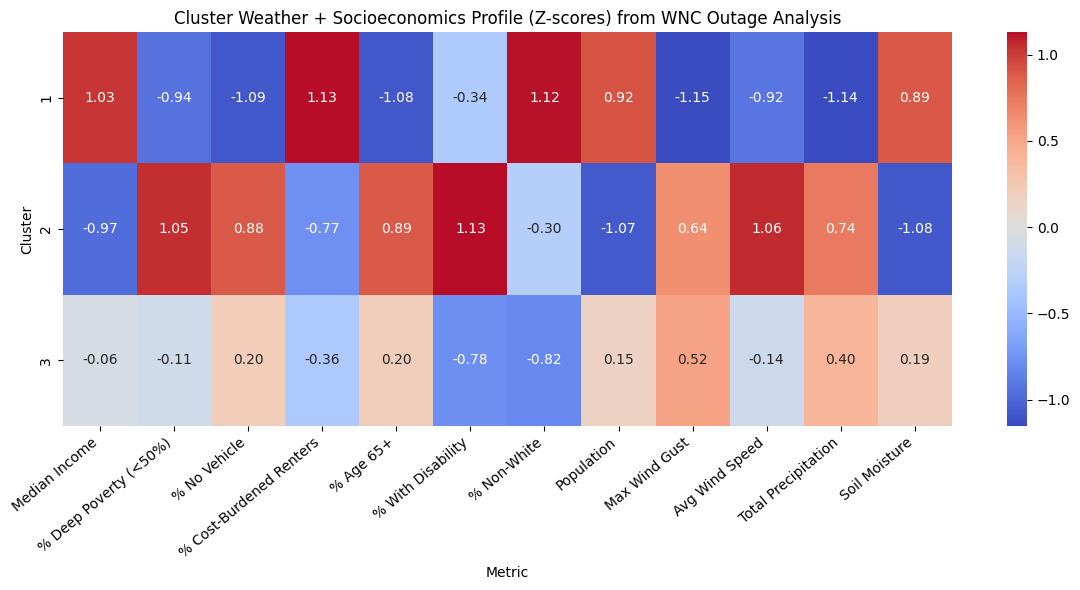

In [53]:
#image creating with the cluster summary

# Columns we want to use (as defined above)
cols = [
    'median_household_income_mean',
    'pct_below_50pct_poverty_mean',
    'pct_no_vehicle_mean',
    'pct_renters_cost_burdened_mean',
    'pct_over65_mean',
    'pct_with_disability_mean',
    'pct_nonwhite_mean',
    'total_population_mean',
    'max_gust_during_outage_days_mean',
    'mean_wind_on_outage_days_mean',
    'total_precip_on_outage_days_mean',
    'mean_soilmoist_on_outage_days_mean'
    
]
#cluster-level z-scores (above/below average)
cluster_summary_std = cluster_summary.copy()
cluster_summary_std[cols] = cluster_summary_std[cols].apply(
    lambda x: (x - x.mean()) / x.std()
)

import seaborn as sns

label_map = {
    'median_household_income_mean': 'Median Income',
    'pct_below_50pct_poverty_mean': '% Deep Poverty (<50%)',
    'pct_no_vehicle_mean': '% No Vehicle',
    'pct_renters_cost_burdened_mean': '% Cost-Burdened Renters',
    'pct_over65_mean': '% Age 65+',
    'pct_with_disability_mean': '% With Disability',
    'pct_nonwhite_mean': '% Non-White',
    'total_population_mean': 'Population',
    'max_gust_during_outage_days_mean': 'Max Wind Gust',
    'mean_wind_on_outage_days_mean': 'Avg Wind Speed',
    'total_precip_on_outage_days_mean': 'Total Precipitation',
    'mean_soilmoist_on_outage_days_mean': 'Soil Moisture'
}

heatmap_data = cluster_summary_std.set_index('cluster')[cols]
heatmap_data = heatmap_data.rename(columns=label_map)
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Cluster Weather + Socioeconomics Profile (Z-scores) from WNC Outage Analysis")
plt.xlabel("Metric")
plt.ylabel("Cluster")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()

plt.savefig(
    'data_processed/outages_pca_results_WNC/heat_map_cluster_weather_socioeconomics.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

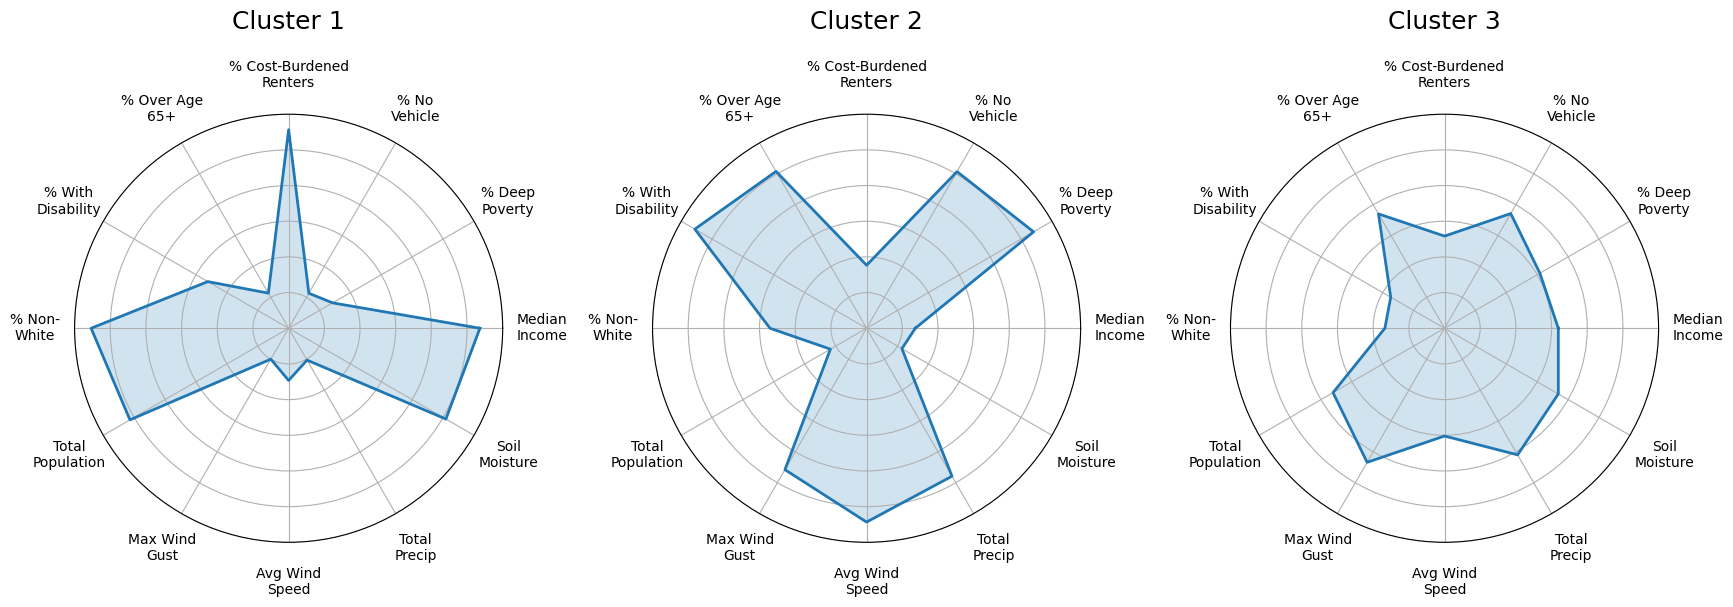

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Columns we want to use
cols = [
    'median_household_income_mean',
    'pct_below_50pct_poverty_mean',
    'pct_no_vehicle_mean',
    'pct_renters_cost_burdened_mean',
    'pct_over65_mean',
    'pct_with_disability_mean',
    'pct_nonwhite_mean',
    'total_population_mean',
    'max_gust_during_outage_days_mean',
    'mean_wind_on_outage_days_mean',
    'total_precip_on_outage_days_mean',
    'mean_soilmoist_on_outage_days_mean',
]

# Cluster-level z-scores
cluster_summary_std = cluster_summary.copy()
cluster_summary_std[cols] = cluster_summary_std[cols].apply(
    lambda x: (x - x.mean()) / x.std()
)

# Two-line labels for radar readability
label_map = {
    'median_household_income_mean': 'Median\nIncome',
    'pct_below_50pct_poverty_mean': '% Deep\nPoverty',
    'pct_no_vehicle_mean': '% No\nVehicle',
    'pct_renters_cost_burdened_mean': '% Cost-Burdened\nRenters',
    'pct_over65_mean': '% Over Age\n65+',
    'pct_with_disability_mean': '% With\nDisability',
    'pct_nonwhite_mean': '% Non-\nWhite',
    'total_population_mean': 'Total\nPopulation',
    'max_gust_during_outage_days_mean': 'Max Wind\nGust',
    'mean_wind_on_outage_days_mean': 'Avg Wind\nSpeed',
    'total_precip_on_outage_days_mean': 'Total\nPrecip',
    'mean_soilmoist_on_outage_days_mean': 'Soil\nMoisture'
}

# Prepare data
radar_data = cluster_summary_std[['cluster'] + cols].copy()
radar_data = radar_data.rename(columns=label_map)

categories = [label_map[c] for c in cols]
N = len(categories)

# Radar axis angles
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Offset values so all radii are positive
all_vals = radar_data[categories].values.flatten()
offset = abs(all_vals.min()) + 0.5
radar_data_plot = radar_data.copy()
radar_data_plot[categories] = radar_data_plot[categories] + offset

rmax = np.ceil((all_vals + offset).max())

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 16), subplot_kw=dict(polar=True))
axes = axes.flatten()

for ax, (_, row) in zip(axes, radar_data_plot.iterrows()):
    cluster_id = int(round(row['cluster']))

    values = row[categories].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.2)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.tick_params(axis='x', pad=18)

    ax.set_yticklabels([])
    ax.set_ylim(0, rmax)

    ax.set_title(f"Cluster {cluster_id}", fontsize=18, pad=22)

plt.subplots_adjust(
    top=0.93,
    bottom=0.06,
    left=0.06,
    right=0.94,
    hspace=0.62,
    wspace=0.35
)

plt.savefig(
    "data_processed/outages_pca_results_WNC/cluster_weather_socioeconomics_radar.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()